In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

In [3]:
#The resource points
bin_points=np.linspace(.001, 0.999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()


## Resource distribution (Gaussian asym)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [5]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [6]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [7]:
#The resource points
bin_points=np.linspace(.001, .999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [8]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [9]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=2 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([.25,.75]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=.1) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=1# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = {'infl_type': 'gaussian'}, learning_rate_type= 'cosine_annealing', learning_rate= [.000001, .000001, 80], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-8, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)
        



In [11]:
stop

NameError: name 'stop' is not defined

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.tri as tri
import matplotlib.colors as colors
from matplotlib.gridspec import GridSpec
import pylab
import imageio.v2 as imageio #For the Gif 
import os
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
import scipy
from matplotlib.collections import LineCollection
import warnings
import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
from functools import partial
import sys
import time
import copy
import traceback
import io
from contextlib import redirect_stdout, redirect_stderr
from mpl_toolkits.mplot3d import Axes3D
from multiprocessing import Pool, cpu_count
import traceback
import plotly.graph_objects as go

import matplotlib.figure
from typing import Union, List, Dict, Optional, Tuple

import InflGame.adaptive.grad_func_env as grad_func_env
#import InflGame.adaptive_dynamics.jacobian as jacobian

import InflGame.utils.general as general
from InflGame.utils import data_management
import InflGame.utils.validation as validation
import InflGame.utils.plot_utils as plot_utils

import InflGame.kernels.gauss as gauss 
import InflGame.kernels.diric as diric
import InflGame.kernels.MV_gauss as MV_gauss
#import InflGame.kernels.jones as jones


import InflGame.domains.rd as rd

import InflGame.domains.one_d.one_utils as one_utils
import InflGame.domains.one_d.one_plots as one_plots


import InflGame.domains.two_d.two_utils as two_utils
import InflGame.domains.two_d.two_plots as two_plots


import InflGame.domains.simplex.simplex_utils as simplex_utils
import InflGame.domains.simplex.simplex_plots as simplex_plots


# Import the new stability analysis module
from InflGame.utils.general import agent_parameter_setup
import InflGame.adaptive.jacobian as jc


def monte_carlo_unit_hypercube(number_samples,seed):
    # Generate m random (x1, x2,...,xn) coordinates in [0, 1]^n
    torch.manual_seed(seed)
    samples = torch.rand(number_samples,vis.num_agents )
    return samples

def gradient_ascent_monte_carlo( 
                                number_samples: int,
                                seed: int,
                                tolerance: float = 10**-5,
                                tolerated_agents: Optional[int] = None,
                                parallel: bool = True,
                                max_workers: Optional[int] = None,
                                batch_size: Optional[int] = None,
                                time_steps: Optional[int] = None) -> torch.Tensor:
    """
    Run gradient ascent using Monte Carlo generated starting positions with parallelization.
    
    This function generates random starting positions using the monte_carlo_unit_hypercube method
    and then runs gradient ascent for each position in parallel, similar to final_pos_over_reach
    but using random initial positions instead of varying parameters.

    :param number_samples: Number of Monte Carlo samples to generate
    :type number_samples: int
    :param seed: Random seed for reproducibility
    :type seed: int
    :param tolerance: Tolerance for convergence
    :type tolerance: float
    :param tolerated_agents: Number of agents allowed to tolerate deviations
    :type tolerated_agents: Optional[int]
    :param parallel: Whether to use parallel processing
    :type parallel: bool
    :param max_workers: Maximum number of parallel workers (defaults to CPU count)
    :type max_workers: Optional[int]
    :param batch_size: Batch size for processing (auto-calculated if None)
    :type batch_size: Optional[int]
    :param time_steps: Maximum time steps for gradient ascent
    :type time_steps: Optional[int]

    :return: The final positions of agents for each Monte Carlo sample
    :rtype: torch.Tensor
    
    :raises ValueError: If input parameters are invalid
    :raises RuntimeError: If computation fails
    """
    # Input validation
    if number_samples <= 0:
        raise ValueError(f"number_samples must be positive, got {number_samples}")
        
    if tolerance <= 0:
        raise ValueError(f"tolerance must be positive, got {tolerance}")
        
    if tolerated_agents is None:
        tolerated_agents = vis.num_agents
    elif tolerated_agents < 0:
        raise ValueError(f"tolerated_agents must be non-negative, got {tolerated_agents}")
    
    # Validate domain type
    if vis.domain_type not in ['1d', '2d', 'simplex']:
        raise ValueError(f"Unsupported domain_type: {vis.domain_type}")
        
    logging.info(f"Running gradient ascent for {number_samples} Monte Carlo samples using domain '{vis.domain_type}'")
    
    # Generate Monte Carlo starting positions
    monte_carlo_positions = monte_carlo_unit_hypercube(number_samples, seed)
    
    # Convert positions to appropriate domain bounds if needed
    if vis.domain_type in ['1d', '2d'] and hasattr(vis, 'domain_bounds'):
        if isinstance(vis.domain_bounds, (list, tuple)) and len(vis.domain_bounds) == 2:
            # Scale from [0,1] to domain bounds
            lower_bound, upper_bound = vis.domain_bounds
            monte_carlo_positions = monte_carlo_positions * (upper_bound - lower_bound) + lower_bound
    
    # Store original state
    try:
        og_parameters = vis.parameters.clone()   
        og_pos = vis.agents_pos.clone()
        og_lr = vis.learning_rate.clone()
        og_tolerance = vis.tolerance
        og_tolerated_agents = vis.tolerated_agents
        
        # Update field tolerance settings
        vis.field.tolerance = tolerance
        vis.field.tolerated_agents = tolerated_agents
        
        # Determine optimal batch size and workers
        if max_workers is None:
            max_workers = min(mp.cpu_count(), number_samples)
        
        if batch_size is None:
            batch_size = max(1, number_samples // max_workers)
        
        # Prepare sample data for parallel processing
        sample_data_list = []
        for sample_id, start_pos in enumerate(monte_carlo_positions):
            sample_data = {
                'sample_id': sample_id,
                'start_pos': start_pos,
                'tolerance': tolerance,
                'tolerated_agents': tolerated_agents,
                'domain_type': vis.domain_type,
                'total_samples': number_samples,
                'time_steps': time_steps
            }
            sample_data_list.append(sample_data)
        
        # Initialize result storage
        final_pos_matrix = 0
        
        if parallel and number_samples > 1:
            # Parallel processing
            logging.info(f"Using parallel processing with {max_workers} workers")
            
            try:
                with ProcessPoolExecutor(max_workers=max_workers) as executor:
                    # Submit all tasks
                    future_to_sample = {
                        executor.submit(_compute_single_monte_carlo_sample, sample_data): sample_data['sample_id']
                        for sample_data in sample_data_list
                    }
                    
                    # Collect results as they complete
                    results = {}
                    completed_count = 0
                    
                    for future in as_completed(future_to_sample):
                        try:
                            sample_id, final_pos_row = future.result()
                            results[sample_id] = final_pos_row
                            completed_count += 1
                            
                            if completed_count % max(1, number_samples // 10) == 0:
                                logging.info(f"Completed {completed_count}/{number_samples} Monte Carlo samples")
                                
                        except Exception as e:
                            sample_id = future_to_sample[future]
                            logging.error(f"Monte Carlo sample {sample_id} failed: {str(e)}")
                            raise RuntimeError(f"Failed to compute Monte Carlo sample {sample_id}: {str(e)}")
                    
                    # Build final matrix from results - vectorized approach
                    # Ensure results are stored in original sample order
                    if len(results) != number_samples:
                        raise RuntimeError(f"Expected {number_samples} results, got {len(results)}")
                    
                    # Create a list to store results in original order
                    ordered_results = [None] * number_samples
                    for sample_id, result in results.items():
                        if sample_id >= number_samples:
                            raise RuntimeError(f"Invalid sample ID {sample_id}, expected 0-{number_samples-1}")
                        ordered_results[sample_id] = result
                    
                    # Check that we have all results
                    if None in ordered_results:
                        missing_ids = [i for i, res in enumerate(ordered_results) if res is None]
                        raise RuntimeError(f"Missing results for sample IDs: {missing_ids}")
                    
                    # Vectorized matrix construction
                    if len(ordered_results) == 1:
                        final_pos_matrix = ordered_results[0]
                    else:
                        final_pos_matrix = torch.stack(ordered_results, dim=0)
                    
                    logging.info(f"Successfully built final position matrix with shape: {final_pos_matrix.shape}")
                        
            except Exception as e:
                logging.error(f"Parallel processing failed: {str(e)}")
                logging.info("Falling back to sequential processing")
                parallel = False
        
        if not parallel:
            # Sequential processing (fallback or by choice)
            logging.info("Using sequential processing")
            
            # Pre-allocate results list for vectorized construction
            final_pos_results = []
            
            for sample_id, start_pos in enumerate(monte_carlo_positions):
                try:
                    # Reset field state
                    vis.field.pos_matrix = 0
                    vis.field.agents_pos = start_pos.clone()
                    vis.agents_pos = start_pos.clone()
                    
                    # Run gradient ascent
                    vis.field.gradient_ascent(show_out=False)
                    
                    # Extract final position
                    if vis.domain_type == 'simplex':
                        final_pos_row = simplex_utils.ba2xy_vectorized(
                            barycentric_coords=vis.field.pos_matrix[-1].clone(),
                            corners=vis.corners
                        )
                    else:
                        final_pos_row = vis.field.pos_matrix[-1].clone()
                    
                    # Store result in order
                    final_pos_results.append(final_pos_row)
                    
                    # Progress logging
                    if (sample_id + 1) % max(1, number_samples // 10) == 0:
                        logging.info(f"Completed {sample_id + 1}/{number_samples} Monte Carlo samples")
                        
                except Exception as e:
                    logging.error(f"Error processing Monte Carlo sample {sample_id}: {str(e)}")
                    raise RuntimeError(f"Failed to process Monte Carlo sample {sample_id}: {str(e)}")
            
            # Vectorized matrix construction for sequential processing
            if len(final_pos_results) == 1:
                final_pos_matrix = final_pos_results[0]
            else:
                final_pos_matrix = torch.stack(final_pos_results, dim=0)
            
            logging.info(f"Successfully built final position matrix with shape: {final_pos_matrix.shape}")
        
        logging.info(f"Successfully completed gradient ascent for all {number_samples} Monte Carlo samples")
        
    except Exception as e:
        logging.error(f"Critical error in gradient_ascent_monte_carlo: {str(e)}")
        raise
        
    finally:
        # Restore original state
        try:
            vis.field.tolerated_agents = og_tolerated_agents
            vis.field.tolerance = og_tolerance 
            vis.field.agents_pos = og_pos.clone()
            vis.field.learning_rate = og_lr.clone()
            vis.agents_pos = og_pos.clone()
            vis.field.parameters = og_parameters
        except Exception as e:
            logging.warning(f"Could not fully restore original state: {str(e)}")
    
    return final_pos_matrix

def _compute_single_monte_carlo_sample( sample_data: Dict) -> Tuple[int, torch.Tensor]:
    """
    Helper function to compute final position for a single Monte Carlo sample.
    Designed to be used with multiprocessing.
    
    :param sample_data: Dictionary containing sample data and configuration
    :type sample_data: Dict
    
    :return: Tuple of sample_id and final position row
    :rtype: Tuple[int, torch.Tensor]
    """
    try:
        sample_id = sample_data['sample_id']
        start_pos = sample_data['start_pos']
        tolerance = sample_data['tolerance']
        tolerated_agents = sample_data['tolerated_agents']
        domain_type = sample_data['domain_type']
        total_samples = sample_data['total_samples']
        time_steps = sample_data['time_steps']
        
        # Create a temporary field environment for this computation
        if domain_type == 'simplex':
            temp_field = grad_func_env.AdaptiveEnv(
                num_agents=vis.num_agents,
                agents_pos=start_pos.clone(),
                parameters=vis.parameters,
                resource_distribution=vis.resource_distribution,
                bin_points=vis.bin_points,
                infl_configs=vis.infl_configs,
                learning_rate_type=vis.learning_rate_type,
                learning_rate=vis.learning_rate,
                time_steps=time_steps,
                fp=vis.fp,
                infl_cshift=vis.infl_cshift,
                cshift=vis.cshift,
                infl_fshift=vis.infl_fshift,
                Q=vis.Q,
                domain_type=domain_type,
                tolerance=tolerance,
                tolerated_agents=tolerated_agents,
                ignore_zero_infl=vis.ignore_zero_infl
            )
        else:
            temp_field = grad_func_env.AdaptiveEnv(
                num_agents=vis.num_agents,
                agents_pos=start_pos.clone(),
                parameters=vis.parameters,
                resource_distribution=vis.resource_distribution,
                bin_points=vis.bin_points,
                infl_configs=vis.infl_configs,
                learning_rate_type=vis.learning_rate_type,
                learning_rate=vis.learning_rate,
                time_steps=time_steps,
                fp=vis.fp,
                infl_cshift=vis.infl_cshift,
                cshift=vis.cshift,
                infl_fshift=vis.infl_fshift,
                Q=vis.Q,
                domain_type=domain_type,
                domain_bounds=vis.domain_bounds,
                tolerance=tolerance,
                tolerated_agents=tolerated_agents,
                ignore_zero_infl=vis.ignore_zero_infl
            )
        
        # Run gradient ascent from the Monte Carlo starting position
        temp_field.gradient_ascent(show_out=False)
        
        # Extract final position
        final_pos_row = temp_field.pos_matrix[-1].clone()
            
        return sample_id, final_pos_row
        
    except Exception as e:
        logging.error(f"Error computing Monte Carlo sample {sample_id}: {str(e)}")
        raise RuntimeError(f"Failed to compute Monte Carlo sample {sample_id}: {str(e)}") from e


In [ ]:
result=gradient_ascent_monte_carlo(
    number_samples=10000,
    seed=42,
    tolerance=1e-5,
    parallel=True,
    max_workers=8,
    time_steps=1000
)

ERROR:root:Monte Carlo sample 0 failed: A process in the process pool was terminated abruptly while the future was running or pending.
ERROR:root:Parallel processing failed: Failed to compute Monte Carlo sample 0: A process in the process pool was terminated abruptly while the future was running or pending.


KeyboardInterrupt: 

Analyzing Monte Carlo results for unique equilibria...
Analyzing 10000 samples with 4 agents each
MONTE CARLO EQUILIBRIUM ANALYSIS
Total samples analyzed: 10000
Number of unique equilibria found: 36
Tolerance used for clustering: 0.0001
Diversity ratio: 0.004
Shannon entropy: 1.861

UNIQUE EQUILIBRIA (sorted by frequency):
------------------------------------------------------------
Equilibrium #1: (frequency: 1729, probability: 0.173)
  Agent 1: 0.745990
  Agent 2: 0.254010
  Agent 3: 0.254010
  Agent 4: 0.745990

Equilibrium #2: (frequency: 1700, probability: 0.170)
  Agent 1: 0.745990
  Agent 2: 0.254010
  Agent 3: 0.745990
  Agent 4: 0.254010

Equilibrium #3: (frequency: 1639, probability: 0.164)
  Agent 1: 0.254010
  Agent 2: 0.745990
  Agent 3: 0.254010
  Agent 4: 0.745990

Equilibrium #4: (frequency: 1632, probability: 0.163)
  Agent 1: 0.254010
  Agent 2: 0.254010
  Agent 3: 0.745990
  Agent 4: 0.745990

Equilibrium #5: (frequency: 1607, probability: 0.161)
  Agent 1: 0.254010


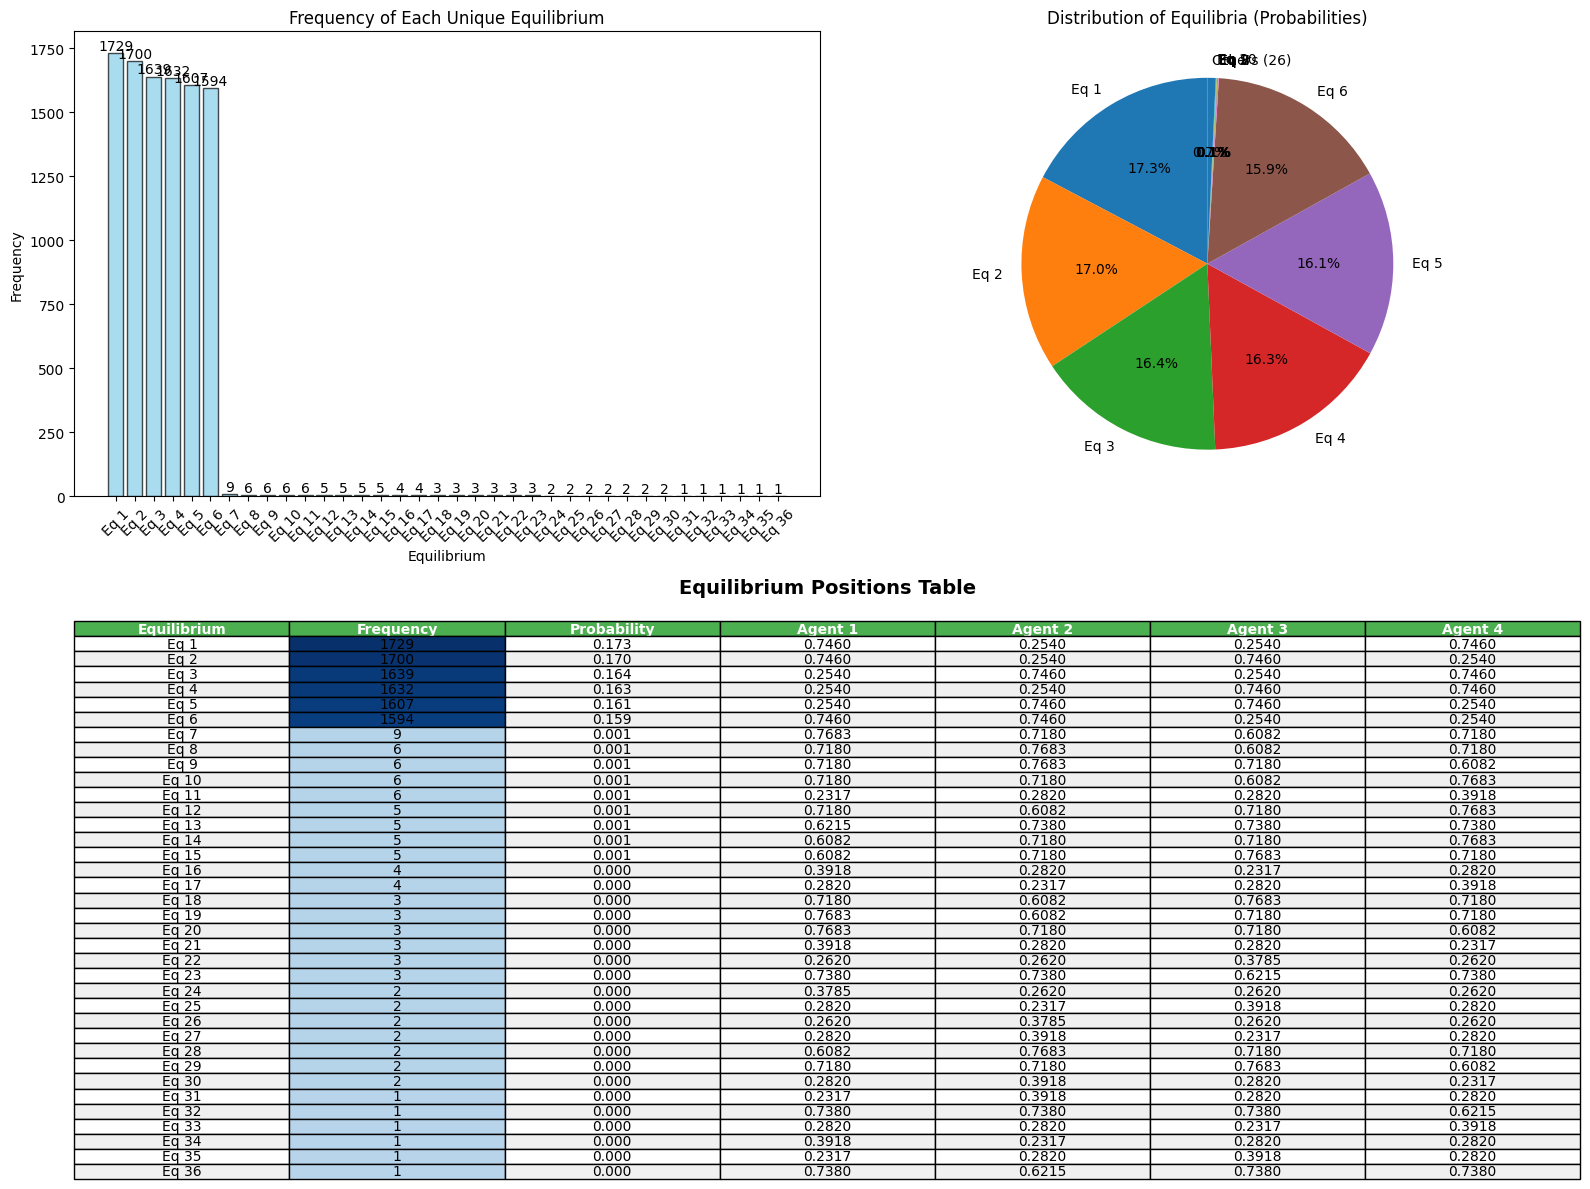


Equilibrium Data as DataFrame:
   Equilibrium  Frequency  Probability  Agent_1_Position  Agent_2_Position  \
0         Eq 1       1729       0.1729            0.7460            0.2540   
1         Eq 2       1700       0.1700            0.7460            0.2540   
2         Eq 3       1639       0.1639            0.2540            0.7460   
3         Eq 4       1632       0.1632            0.2540            0.2540   
4         Eq 5       1607       0.1607            0.2540            0.7460   
5         Eq 6       1594       0.1594            0.7460            0.7460   
6         Eq 7          9       0.0009            0.7683            0.7180   
7         Eq 8          6       0.0006            0.7180            0.7683   
8         Eq 9          6       0.0006            0.7180            0.7683   
9        Eq 10          6       0.0006            0.7180            0.7180   
10       Eq 11          6       0.0006            0.2317            0.2820   
11       Eq 12          5       

In [ ]:
def analyze_unique_equilibria(result_tensor, tolerance=1e-4):
    """
    Analyze Monte Carlo results to find unique equilibria and their frequencies.
    
    :param result_tensor: Tensor of final positions from Monte Carlo runs
    :type result_tensor: torch.Tensor
    :param tolerance: Tolerance for considering positions as "near-unique"
    :type tolerance: float
    
    :return: Dictionary with unique equilibria, frequencies, and statistics
    :rtype: dict
    """
    
    if result_tensor.dim() == 1:
        # Single sample case - reshape to 2D
        result_tensor = result_tensor.unsqueeze(0)
    
    num_samples, num_agents = result_tensor.shape
    print(f"Analyzing {num_samples} samples with {num_agents} agents each")
    
    # Convert to numpy for easier manipulation
    positions = result_tensor.cpu().numpy()
    
    # Find unique equilibria using clustering approach
    unique_equilibria = []
    frequencies = []
    sample_assignments = []  # Which unique equilibrium each sample belongs to
    
    for i, pos in enumerate(positions):
        # Check if this position is close to any existing unique equilibrium
        found_match = False
        
        for j, unique_pos in enumerate(unique_equilibria):
            # Calculate Euclidean distance between positions
            distance = np.linalg.norm(pos - unique_pos)
            
            if distance < tolerance:
                # This position is close enough to an existing unique equilibrium
                frequencies[j] += 1
                sample_assignments.append(j)
                found_match = True
                break
        
        if not found_match:
            # This is a new unique equilibrium
            unique_equilibria.append(pos.copy())
            frequencies.append(1)
            sample_assignments.append(len(unique_equilibria) - 1)
    
    # Convert to numpy arrays first
    unique_equilibria_array = np.array(unique_equilibria)
    frequencies_array = np.array(frequencies)
    
    # Sort by frequency (most common first) - fix for negative stride issue
    sorted_indices = np.argsort(frequencies_array)[::-1].copy()  # Add .copy() to avoid negative stride
    unique_equilibria_sorted = unique_equilibria_array[sorted_indices].copy()  # Make copy for tensor conversion
    frequencies_sorted = frequencies_array[sorted_indices].copy()  # Make copy
    
    # Convert to tensor after sorting
    unique_equilibria_tensor = torch.tensor(unique_equilibria_sorted)
    
    # Calculate statistics
    num_unique = len(unique_equilibria)
    total_samples = num_samples
    
    # Calculate diversity metrics
    shannon_entropy = -np.sum((frequencies_sorted / total_samples) * 
                             np.log(frequencies_sorted / total_samples))
    
    # Most common equilibrium statistics
    most_common_freq = frequencies_sorted[0] if num_unique > 0 else 0
    most_common_prob = most_common_freq / total_samples if total_samples > 0 else 0
    
    results = {
        'unique_equilibria': unique_equilibria_tensor,
        'frequencies': frequencies_sorted,
        'sample_assignments': np.array(sample_assignments),
        'num_unique': num_unique,
        'total_samples': total_samples,
        'tolerance_used': tolerance,
        'shannon_entropy': shannon_entropy,
        'most_common_frequency': most_common_freq,
        'most_common_probability': most_common_prob,
        'diversity_ratio': num_unique / total_samples if total_samples > 0 else 0
    }
    
    return results

def print_equilibrium_analysis(analysis_results):
    """
    Print a detailed analysis of the equilibrium results.
    
    :param analysis_results: Results from analyze_unique_equilibria
    :type analysis_results: dict
    """
    
    print("="*60)
    print("MONTE CARLO EQUILIBRIUM ANALYSIS")
    print("="*60)
    
    print(f"Total samples analyzed: {analysis_results['total_samples']}")
    print(f"Number of unique equilibria found: {analysis_results['num_unique']}")
    print(f"Tolerance used for clustering: {analysis_results['tolerance_used']}")
    print(f"Diversity ratio: {analysis_results['diversity_ratio']:.3f}")
    print(f"Shannon entropy: {analysis_results['shannon_entropy']:.3f}")
    print()
    
    print("UNIQUE EQUILIBRIA (sorted by frequency):")
    print("-" * 60)
    
    unique_equilibria = analysis_results['unique_equilibria']
    frequencies = analysis_results['frequencies']
    total_samples = analysis_results['total_samples']
    
    for i, (equilibrium, freq) in enumerate(zip(unique_equilibria, frequencies)):
        probability = freq / total_samples
        print(f"Equilibrium #{i+1}: (frequency: {freq}, probability: {probability:.3f})")
        
        # Print agent positions
        for j, pos in enumerate(equilibrium):
            print(f"  Agent {j+1}: {pos:.6f}")
        
        # Add spacing between equilibria
        if i < len(unique_equilibria) - 1:
            print()
    
    print("\n" + "="*60)
    print(f"Most common equilibrium appears in {analysis_results['most_common_probability']:.1%} of samples")
    print("="*60)

def visualize_equilibrium_clustering(analysis_results, original_results):
    """
    Create visualizations for the equilibrium clustering analysis.
    
    :param analysis_results: Results from analyze_unique_equilibria
    :param original_results: Original Monte Carlo results tensor
    """
    
    # Create figure with 2x2 subplot layout
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.2])
    
    # Top row - original plots
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Bottom row - table spanning both columns
    ax_table = fig.add_subplot(gs[1, :])
    
    # 1. Frequency bar chart
    frequencies = analysis_results['frequencies']
    equilibrium_labels = [f"Eq {i+1}" for i in range(len(frequencies))]
    
    bars = ax1.bar(equilibrium_labels, frequencies, 
                   color='skyblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Equilibrium')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Frequency of Each Unique Equilibrium')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add frequency labels on bars
    for bar, freq in zip(bars, frequencies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{freq}', ha='center', va='bottom')
    
    # 2. Probability pie chart (top 10 equilibria only)
    top_n = min(10, len(frequencies))
    top_frequencies = frequencies[:top_n]
    remaining_freq = np.sum(frequencies[top_n:]) if len(frequencies) > top_n else 0
    
    if remaining_freq > 0:
        pie_frequencies = np.append(top_frequencies, remaining_freq)
        pie_labels = equilibrium_labels[:top_n] + [f"Others ({len(frequencies)-top_n})"]
    else:
        pie_frequencies = top_frequencies
        pie_labels = equilibrium_labels[:top_n]
    
    ax2.pie(pie_frequencies, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribution of Equilibria (Probabilities)')
    
    # 3. Create equilibrium positions table
    unique_equilibria = analysis_results['unique_equilibria']
    num_agents = unique_equilibria.shape[1]
    
    # Prepare table data
    table_data = []
    column_labels = ['Equilibrium', 'Frequency', 'Probability'] + [f'Agent {i+1}' for i in range(num_agents)]
    
    for i, (equilibrium, freq) in enumerate(zip(unique_equilibria, frequencies)):
        probability = freq / analysis_results['total_samples']
        row = [f"Eq {i+1}", str(freq), f"{probability:.3f}"]
        # Add agent positions
        for pos in equilibrium:
            row.append(f"{pos:.4f}")
        table_data.append(row)
    
    # Create table
    ax_table.axis('tight')
    ax_table.axis('off')
    
    # Create the table
    table = ax_table.table(cellText=table_data,
                          colLabels=column_labels,
                          cellLoc='center',
                          loc='center',
                          bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color the header row
    for i in range(len(column_labels)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors for better readability
    for i in range(1, len(table_data) + 1):
        for j in range(len(column_labels)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')
            else:
                table[(i, j)].set_facecolor('white')
    
    # Color frequency column based on values
    max_freq = max(frequencies) if frequencies.size > 0 else 1
    for i, freq in enumerate(frequencies):
        # Color intensity based on frequency
        intensity = freq / max_freq
        color_intensity = 0.3 + 0.7 * intensity  # Range from 0.3 to 1.0
        table[(i+1, 1)].set_facecolor(plt.cm.Blues(color_intensity))
    
    ax_table.set_title('Equilibrium Positions Table', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Also create a pandas DataFrame for easy data manipulation
    import pandas as pd
    
    # Create DataFrame
    df_data = {
        'Equilibrium': [f"Eq {i+1}" for i in range(len(frequencies))],
        'Frequency': frequencies,
        'Probability': frequencies / analysis_results['total_samples']
    }
    
    # Add agent position columns
    for i in range(num_agents):
        df_data[f'Agent_{i+1}_Position'] = unique_equilibria[:, i]
    
    equilibrium_df = pd.DataFrame(df_data)
    
    print("\nEquilibrium Data as DataFrame:")
    print("="*60)
    print(equilibrium_df.round(4))
    
    return equilibrium_df

# Analyze the Monte Carlo results
if 'result' in locals() and result is not None:
    print("Analyzing Monte Carlo results for unique equilibria...")
    
    # You can adjust the tolerance based on your precision needs
    # Smaller tolerance = more strict uniqueness criteria
    equilibrium_analysis = analyze_unique_equilibria(result, tolerance=1e-4)
    
    # Print detailed analysis
    print_equilibrium_analysis(equilibrium_analysis)
    
    # Create visualizations and get DataFrame
    equilibrium_df = visualize_equilibrium_clustering(equilibrium_analysis, result)
    
else:
    print("No Monte Carlo results found. Please run the gradient_ascent_monte_carlo function first.")